<a href="https://colab.research.google.com/github/espindolaleticia/cp2_sers/blob/main/cp2_01sers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EXERCÍCIO
Treinar um modelo de classificação usando o algortimo de regressão logística (no sklearn ---> logistic regression) para prever se a rede elétrica está INSTÁVEL ou ESTÁVEL. Métricas para avaliação: acurácia, precisão e a matriz de confusão.

Qual será o atributo alvo y (target)? ---> coluna 'stabf' com duas classes 'stable' e 'unstable'

Quais serão as nossas features (X) ---> todos os atributos, exceto 'stab' e 'stabf'

## PREPARAÇÃO DO AMBIENTE

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

# stable: 0 unstable: 1
# REGISTRO 0 ---> [0.9995 | 0.0005]

CARREGAR OS DADOS DO ARQUIVO DA PASTA DO GitHub USANDO PANDAS (read_csv)

In [ ]:
# faça uma inspeção nos dados
# quais classes existem na coluna alvo "stabf"?
# quantos registros temos de cada classe?
# separar features(X) e target (Y)
# separar dados de treino e teste
# instanciar o objeto 'modelo' a partir da classe LogisticRegresion
# treinar, gerar prvisões e avaliar

In [ ]:
#inspeção de dados
dados = pd.read_csv ('https://raw.githubusercontent.com/espindolaleticia/cp2_sers/refs/heads/main/Data_for_UCI_named.csv')
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [ ]:
dados.shape
print(f'Registros: {dados.shape[0]}')
print(f'Colunas: {dados.shape[1]}')

Registros: 10000
Colunas: 14


In [ ]:
dados.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [ ]:
#atributos com dados categoricos
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [ ]:
#atributos com dados numericos
dados.describe(include='number')

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [ ]:
#renomeando labels das classes
dados['stabf'] = dados ['stabf'].replace({'unstable': 'REDE INSTAVEL', 'stabel': 'REDE ESTAVEL'})
dados.head(15)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,REDE INSTAVEL
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,REDE INSTAVEL
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,REDE INSTAVEL
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,REDE INSTAVEL
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,-0.017385,stable
6,6.710166,3.765204,6.929314,8.818562,2.397419,-0.614590,-1.208826,-0.574004,0.177890,0.397977,0.402046,0.376630,0.005954,REDE INSTAVEL
7,6.953512,1.379125,5.719400,7.870307,3.224495,-0.748998,-1.186517,-1.288980,0.371385,0.633204,0.732741,0.380544,0.016634,REDE INSTAVEL
8,4.689852,4.007747,1.478573,3.733787,4.041300,-1.410344,-1.238204,-1.392751,0.269708,0.250364,0.164941,0.482439,-0.038677,stable
9,9.841496,1.413822,9.769856,7.641616,4.727595,-1.991363,-0.857637,-1.878594,0.376356,0.544415,0.792039,0.116263,0.012383,REDE INSTAVEL


In [ ]:
#quais classes existem na coluna alvo "stabf"?
dados['stabf'].unique()

array(['REDE INSTAVEL', 'stable'], dtype=object)

In [ ]:
#quantos registros temos de cada classe?
dados['stabf'].value_counts()

,count
stabf,
REDE INSTAVEL,6380
stable,3620


In [ ]:
#features
X = dados.drop(['stab', 'stabf'], axis=1)
X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [ ]:
#separar target(y)
y = dados['stabf']
y.head()

,stabf
0,REDE INSTAVEL
1,stable
2,REDE INSTAVEL
3,REDE INSTAVEL
4,REDE INSTAVEL


In [ ]:
#separar dados de treino de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#instanciar
from sklearn.linear_model import LogisticRegression
modelo = LogisticRegression()

In [ ]:
#treinar
from sklearn.linear_model import LogisticRegression
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

LogisticRegression()

In [ ]:
#gerar as probabilidades
y_prob = modelo.predict_proba(X_test)
y_prob[:50]

array([[0.95390652, 0.04609348],
       [0.93917366, 0.06082634],
       [0.68334811, 0.31665189],
       [0.02154553, 0.97845447],
       [0.35511263, 0.64488737],
       [0.42689736, 0.57310264],
       [0.2706692 , 0.7293308 ],
       [0.9779631 , 0.0220369 ],
       [0.95544762, 0.04455238],
       [0.25736175, 0.74263825],
       [0.94178328, 0.05821672],
       [0.56460389, 0.43539611],
       [0.45178954, 0.54821046],
       [0.77371863, 0.22628137],
       [0.98261955, 0.01738045],
       [0.75940251, 0.24059749],
       [0.56616746, 0.43383254],
       [0.80764943, 0.19235057],
       [0.57043125, 0.42956875],
       [0.69084929, 0.30915071],
       [0.91672017, 0.08327983],
       [0.8714353 , 0.1285647 ],
       [0.80994571, 0.19005429],
       [0.22978019, 0.77021981],
       [0.65485941, 0.34514059],
       [0.70844535, 0.29155465],
       [0.38598699, 0.61401301],
       [0.51803737, 0.48196263],
       [0.30424115, 0.69575885],
       [0.07096656, 0.92903344],
       [0.

In [ ]:
#gerar previsoes
y_pred = modelo.predict(X_test)
y_pred[:50]

array(['REDE INSTAVEL', 'REDE INSTAVEL', 'REDE INSTAVEL', 'stable',
       'stable', 'stable', 'stable', 'REDE INSTAVEL', 'REDE INSTAVEL',
       'stable', 'REDE INSTAVEL', 'REDE INSTAVEL', 'stable',
       'REDE INSTAVEL', 'REDE INSTAVEL', 'REDE INSTAVEL', 'REDE INSTAVEL',
       'REDE INSTAVEL', 'REDE INSTAVEL', 'REDE INSTAVEL', 'REDE INSTAVEL',
       'REDE INSTAVEL', 'REDE INSTAVEL', 'stable', 'REDE INSTAVEL',
       'REDE INSTAVEL', 'stable', 'REDE INSTAVEL', 'stable', 'stable',
       'REDE INSTAVEL', 'stable', 'stable', 'REDE INSTAVEL',
       'REDE INSTAVEL', 'REDE INSTAVEL', 'stable', 'stable',
       'REDE INSTAVEL', 'REDE INSTAVEL', 'REDE INSTAVEL', 'REDE INSTAVEL',
       'REDE INSTAVEL', 'stable', 'stable', 'REDE INSTAVEL', 'stable',
       'REDE INSTAVEL', 'stable', 'stable'], dtype=object)

In [ ]:
#acuracia
accuracy = 100 * accuracy_score(y_test, y_pred)
print(f'Acurácia: {accuracy:.2f}')


Acurácia: 81.70


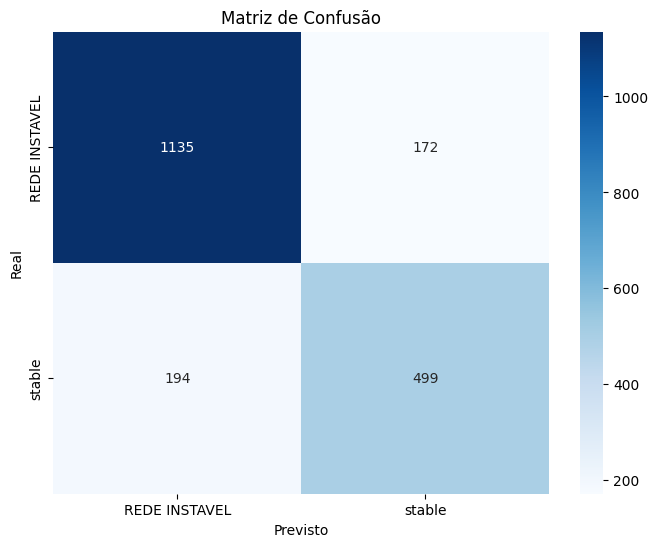

In [ ]:
#gerar a matriz de confusao, usando heatmap e seaborn
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo.classes_, yticklabels=modelo.classes_)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()